# **Manga Readers Are Mad (Or Not?): Analyzing Fan Sentiment on Anime Adaptations — What The Community Really Thinks**

If you've ever been in an anime discussion, you know the drill: "The manga was better," "They ruined the pacing," "Why did they censor that scene?" Fans are passionate and often critical when their favorite manga gets adapted. But what do they actually complain about the most? This study analyzes over 1,000 fan comments of 11 anime series scraped from multiple platforms: Reddit, TikTok, myAnimeList, etc. Specifically from posts that are asking or comparing the anime with its source material (manga). We break down sentiment by aspect, not just counting likes and dislikes, but digging into *why* fans feel the way they do, which aspects drive positive reactions, and what consistently triggers negative backlash.

## **1. Setup and Data Loading**


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
!pip install wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Load data (upload the CSV file to Colab first)
df = pd.read_csv('Anime vs manga - cleaned_anime_data.csv')

# Display first rows
print("Data shape:", df.shape)
df.head()

Data shape: (1780, 5)


,Anime,Text,Overall,Aspect,Sentiment
0,Naruto,Manga is great for understanding the story and...,neutral,"['Fidelity', 'Animation']","['negative', 'positive']"
1,Naruto,Very true Sasori vs Chiyo and Sakura in the ma...,neutral,['Animation'],['positive']
2,Naruto,shippuden was heavily dragged out and riddled ...,negative,"['Fidelity', 'Pacing']","['negative', 'negative']"
3,Naruto,Sakura and chiyo vs sasori had very little fil...,positive,['Pacing'],['negative']
4,Naruto,What? The sakura/Chiyo VS Sasori fight lasts f...,neutral,['Pacing'],['positive']


## **2. Data Cleaning & Preparation**

In [ ]:
import ast
import numpy as np

# Parsing
def parse_list(x):
    if pd.isna(x):
        return []
    try:
        # Mengubah string literal list menjadi list Python
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        # Fallback: jika format tidak sesuai, kembalikan list kosong
        return []

# Apply parsing
df['aspect_list'] = df['Aspect'].apply(parse_list)
df['sentiment_list'] = df['Sentiment'].apply(parse_list)

# Overall sentiment to numerical mapping
sentiment_map = {'positive': 1, 'negative': -1, 'neutral': 0}
df['sentiment_num'] = df['Overall'].map(sentiment_map)

# --- 3. Explode data untuk analisis per aspek ---
df_expanded = df.explode('aspect_list').explode('sentiment_list')
# Hapus baris yang kosong (aspek atau sentimen tidak ada)
df_expanded = df_expanded[
    (df_expanded['aspect_list'] != '') &
    (df_expanded['sentiment_list'] != '') &
    (df_expanded['aspect_list'].notna()) &
    (df_expanded['sentiment_list'].notna())
].copy()

# Additional Columns
df_expanded['aspect_clean'] = df_expanded['aspect_list']
df_expanded['sentiment_clean'] = df_expanded['sentiment_list']

# Ensure aspect_clean and sentiment_clean contain hashable types (strings)
# This handles cases where, after explode, some entries might still be lists
# (e.g., if the original 'Aspect' column had nested lists like "[['Fidelity']]")
def flatten_and_to_string(value):
    if isinstance(value, list):
        return str(value[0]) if len(value) > 0 else ''
    return str(value)

df_expanded['aspect_clean'] = df_expanded['aspect_clean'].apply(flatten_and_to_string)
df_expanded['sentiment_clean'] = df_expanded['sentiment_clean'].apply(flatten_and_to_string)

print("Data shape after cleaning:", df.shape)
print("Expanded shape:", df_expanded.shape)

# Diagnostic: Check types in aspect_clean before nunique()
print("Types in 'aspect_clean' before nunique():")
print(df_expanded['aspect_clean'].apply(type).value_counts())

print("Unique aspects:", df_expanded['aspect_clean'].nunique())

df.head()

Data shape after cleaning: (1780, 8)
Expanded shape: (4154, 10)
Types in 'aspect_clean' before nunique():
aspect_clean
<class 'str'>    4154
Name: count, dtype: int64
Unique aspects: 11


,Anime,Text,Overall,Aspect,Sentiment,aspect_list,sentiment_list,sentiment_num
0,Naruto,Manga is great for understanding the story and...,neutral,"['Fidelity', 'Animation']","['negative', 'positive']","[Fidelity, Animation]","[negative, positive]",0
1,Naruto,Very true Sasori vs Chiyo and Sakura in the ma...,neutral,['Animation'],['positive'],[Animation],[positive],0
2,Naruto,shippuden was heavily dragged out and riddled ...,negative,"['Fidelity', 'Pacing']","['negative', 'negative']","[Fidelity, Pacing]","[negative, negative]",-1
3,Naruto,Sakura and chiyo vs sasori had very little fil...,positive,['Pacing'],['negative'],[Pacing],[negative],1
4,Naruto,What? The sakura/Chiyo VS Sasori fight lasts f...,neutral,['Pacing'],['positive'],[Pacing],[positive],0


## **3. Analysis**

In [ ]:
anime_data_counts = df['Anime'].value_counts()
print("Number of data for each Series:")
print(anime_data_counts)

Number of data for each Series:
Anime
Naruto                    289
Hunter x Hunter           238
Demon Slayer              230
Tokyo Ghoul               211
One Piece                 140
Mob Psycho 100            134
Gintama                   116
Bleach                    109
K-On                      105
The Promised Neverland    104
One Punch Man             104
Name: count, dtype: int64


In [31]:
print(f"Jumlah aspek unik: {df_expanded['aspect_clean'].nunique()}")
print(f"Daftar aspek unik: {df_expanded['aspect_clean'].unique().tolist()}")
print(f"\nJumlah sentimen unik (per aspek): {df_expanded['sentiment_clean'].nunique()}")
print(f"Daftar sentimen unik (per aspek): {df_expanded['sentiment_clean'].unique().tolist()}")
print(f"\nJumlah sentimen unik (keseluruhan): {df['Overall'].nunique()}")
print(f"Daftar sentimen unik (keseluruhan): {df['Overall'].unique().tolist()}")

Jumlah aspek unik: 11
Daftar aspek unik: ['Fidelity', 'Animation', 'Pacing', 'Voice Acting', 'Music/OST', 'Art Style', 'Censorship', 'Characterization', 'Expansion', 'Tone/Atmosphere', 'Production/Staff']

Jumlah sentimen unik (per aspek): 3
Daftar sentimen unik (per aspek): ['negative', 'positive', 'neutral']

Jumlah sentimen unik (keseluruhan): 3
Daftar sentimen unik (keseluruhan): ['neutral', 'negative', 'positive']


### **A. Overall Sentiment: Are Fans Mostly Happy or Disappointed?**
Before diving into details, let's look at the big picture. When comparing anime to manga, do fans tend to be positive, negative, or neutral? This baseline helps us understand the general mood of the conversation.

/tmp/ipykernel_63527/2765038426.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall_sentiment_counts.index, y=overall_sentiment_counts.values,


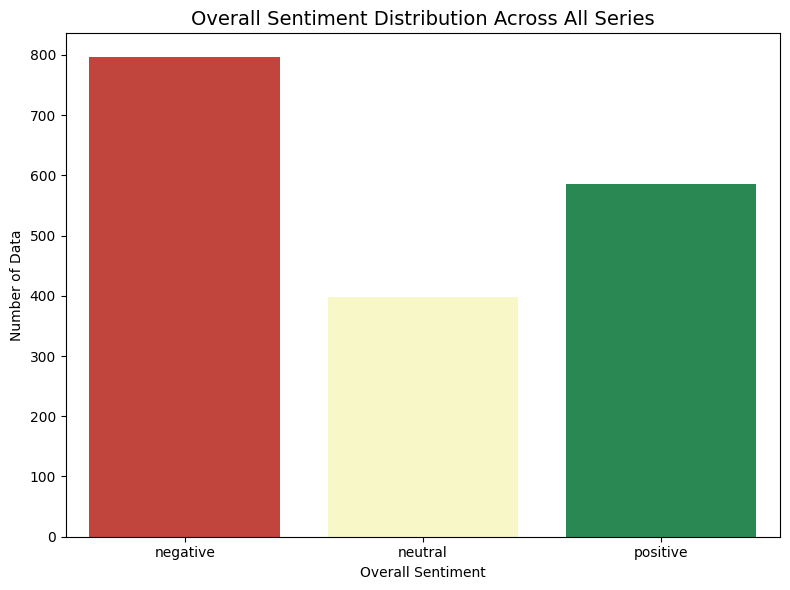

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the total counts for each 'Overall' sentiment class
overall_sentiment_counts = df['Overall'].value_counts()

# Reorder for consistent plotting (optional, but good practice)
overall_sentiment_counts = overall_sentiment_counts.reindex(['negative', 'neutral', 'positive'])

plt.figure(figsize=(8, 6))
sns.barplot(x=overall_sentiment_counts.index, y=overall_sentiment_counts.values,
            palette=['#d73027', '#ffffbf', '#1a9850'])
plt.title('Overall Sentiment Distribution Across All Series', fontsize=14)
plt.xlabel('Overall Sentiment')
plt.ylabel('Number of Data')
plt.tight_layout()
plt.show()

In [33]:
print('Exact counts for Overall Sentiment:')
print(overall_sentiment_counts)

Exact counts for Overall Sentiment:
Overall
negative    796
neutral     398
positive    586
Name: count, dtype: int64


**Findings:**

Negative leads with 796 comments (44.7%), followed by Positive with 586 (32.9%), and Neutral is lowest at 398 (22.4%). This suggests discussions are more critical than appreciative, although positive opinions remain substantial. Neutral takes are comparatively less common, indicating that users often express clear preferences when discussing anime and manga adaptations.

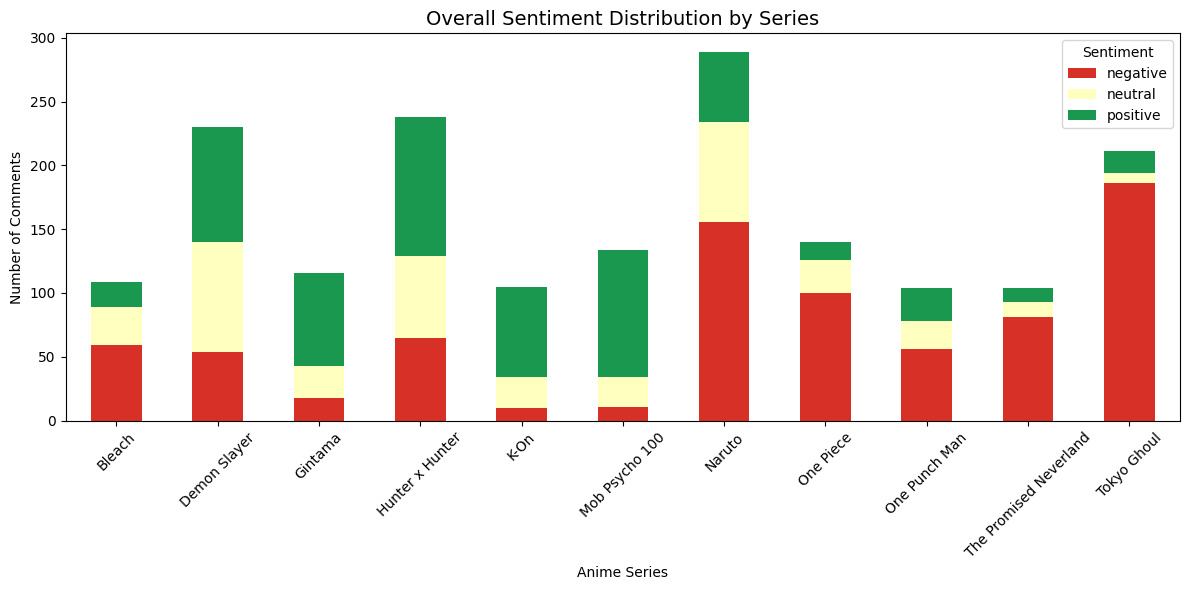

In [34]:
sentiment_counts = df.groupby(['Anime', 'Overall']).size().unstack(fill_value=0)
# Reorder columns
sentiment_counts = sentiment_counts[['negative', 'neutral', 'positive']]

ax = sentiment_counts.plot(kind='bar', stacked=True, figsize=(12,6),
                           color=['#d73027', '#ffffbf', '#1a9850'])
ax.set_title('Overall Sentiment Distribution by Series', fontsize=14)
ax.set_xlabel('Anime Series')
ax.set_ylabel('Number of Comments')
ax.legend(title='Sentiment')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [35]:
print('Exact counts of Overall Sentiment Distribution by Series:')
display(sentiment_counts)

Exact counts of Overall Sentiment Distribution by Series:


Overall,negative,neutral,positive
Anime,,,
Bleach,59,30,20
Demon Slayer,54,86,90
Gintama,18,25,73
Hunter x Hunter,65,64,109
K-On,10,24,71
Mob Psycho 100,11,23,100
Naruto,156,78,55
One Piece,100,26,14
One Punch Man,56,22,26


**Findings:**

- **One Piece**, **The Promised Neverland**, and **Tokyo Ghoul**: These series exhibit very strong negative sentiment. **One Piece** has 100 (71.4%) negative, 26 (18.6%) neutral, 14 (10.0%) positive. **The Promised Neverland** shows 81 (77.9%) negative, 12 (11.5%) neutral, 11 (10.6%) positive. **Tokyo Ghoul** has 186 (88.2%) negative, 8 (3.8%) neutral, 17 (8.1%) positive.

- **Naruto** and **Bleach**: These lean negative, with over half negative. **Naruto** has 156 (54.0%) negative, 78 (27.0%) neutral, and 55 (19.0%) positive. **Bleach** has 59 (54.1%) negative, 30 (27.5%) neutral, and 20 (18.3%) positive.

- **K-On**, **Mob Psycho 100**, and **Gintama**: These series show overwhelmingly positive sentiment. **K-On** has 71 (67.6%) positive, 24 (22.9%) neutral, and 10 (9.5%) negative. **Mob Psycho 100** has 100 (74.6%) positive, 23 (17.2%) neutral, and 11 (8.2%) negative. **Gintama** has 73 (63.5%) positive, 25 (21.7%) neutral, and 18 (15.7%) negative.

- **Hunter x Hunter** and **Demon Slayer**: Positive sentiment is the largest category, although not dominant. **Hunter x Hunter** records 109 (45.8%) positive, 65 (27.3%) negative, and 64 (26.9%) neutral. **Demon Slayer** shows 90 (39.1%) positive, 86 (37.4%) neutral, and 54 (23.5%) negative.

- **One Punch Man**: Sentiment is more mixed, though negative opinions remain the largest portion. It has 56 (53.8%) negative, 26 (25.0%) positive, and 22 (21.2%) neutral.

### **B. Most Discussed Aspects: What Do Fans Care About Most?**
Now we know the overall sentiment, but what exactly are they talking about? By counting how often each aspect appears, we identify what fans prioritize when judging an adaptation. This sets the stage for deeper dives in the following sections.

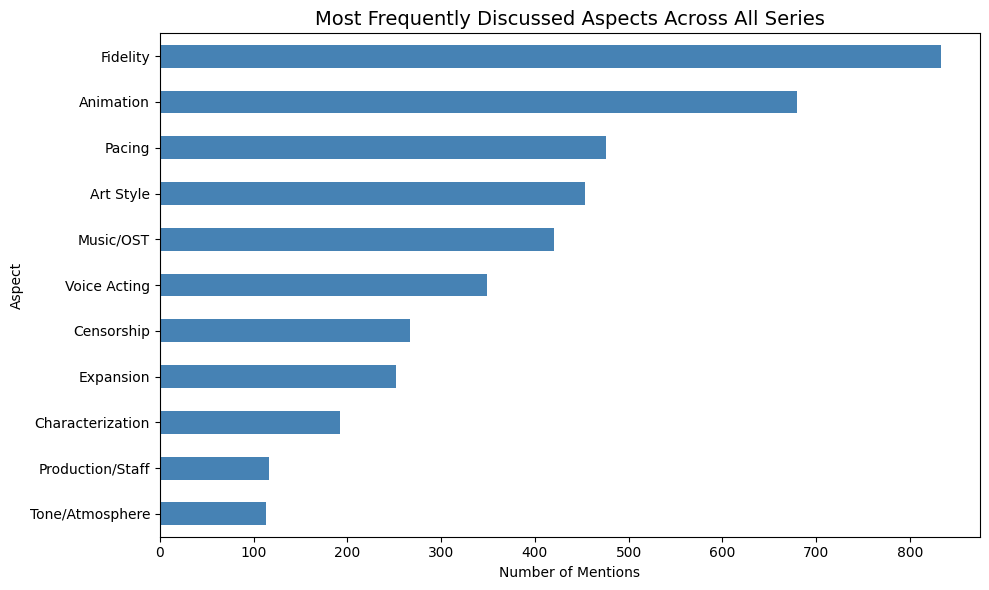

In [37]:
all_aspects = df_expanded['aspect_list'].value_counts()
top_aspects = all_aspects.head(11)

plt.figure(figsize=(10,6))
top_aspects.sort_values().plot(kind='barh', color='steelblue')
plt.title('Most Frequently Discussed Aspects Across All Series', fontsize=14)
plt.xlabel('Number of Mentions')
plt.ylabel('Aspect')
plt.tight_layout()
plt.show()

In [38]:
print('Exact counts of Most Frequently Discussed Aspects Across All Series:')
display(top_aspects)

Exact counts of Most Frequently Discussed Aspects Across All Series:


,count
aspect_list,
Fidelity,833
Animation,680
Pacing,476
Art Style,453
Music/OST,420
Voice Acting,349
Censorship,267
Expansion,252
Characterization,192


**Findings:**

- 'Fidelity' is the most discussed aspect (833 mentions, 20.7%), indicating faithfulness to source material remains the primary fan concern. It leads by a large margin, with 153 more mentions than the second-ranked aspect.

- 'Animation' (680, 16.9%) and 'Pacing' (476, 11.8%) rank next, highlighting the importance of both visual quality and narrative flow in adaptation discussions.

- 'Art Style' (453, 11.3%) and 'Music/OST' (420, 10.4%) follow closely, showing that aesthetic presentation and audio experience are also major factors influencing audience perception.

- 'Voice Acting' (349, 8.7%), 'Censorship' (267, 6.6%), 'Expansion' (252, 6.3%), and 'Characterization' (192, 4.8%) form the mid-tier discussion group, reflecting secondary but still meaningful evaluation criteria in adaptation analysis.

- Lower-frequency aspects include 'Production/Staff' (116, 2.9%) and 'Tone/Atmosphere' (113, 2.8%), suggesting that behind-the-scenes factors and overall mood/feel of a series are less frequently discussed compared to core adaptation and execution elements.

The dominance of 'Fidelity' suggests that source-material faithfulness remains the central topic in anime-versus-manga discussions. Meanwhile, the strong presence of 'Animation', 'Pacing', and 'Art Style' indicates that execution quality remains nearly as important as adaptation accuracy when audiences evaluate an adaptation.

### **C. Net Sentiment Heatmap: Who Gets Praised and Criticized (and for What)?**
Frequency alone isn't enough. We need to know whether each aspect receives praise or criticism, and for which series. By calculating net sentiment (positive minus negative mentions) per aspect per series, this heatmap reveals patterns: which aspects are usually positive, which are polarizing, and how each series has its own unique sentiment profile.

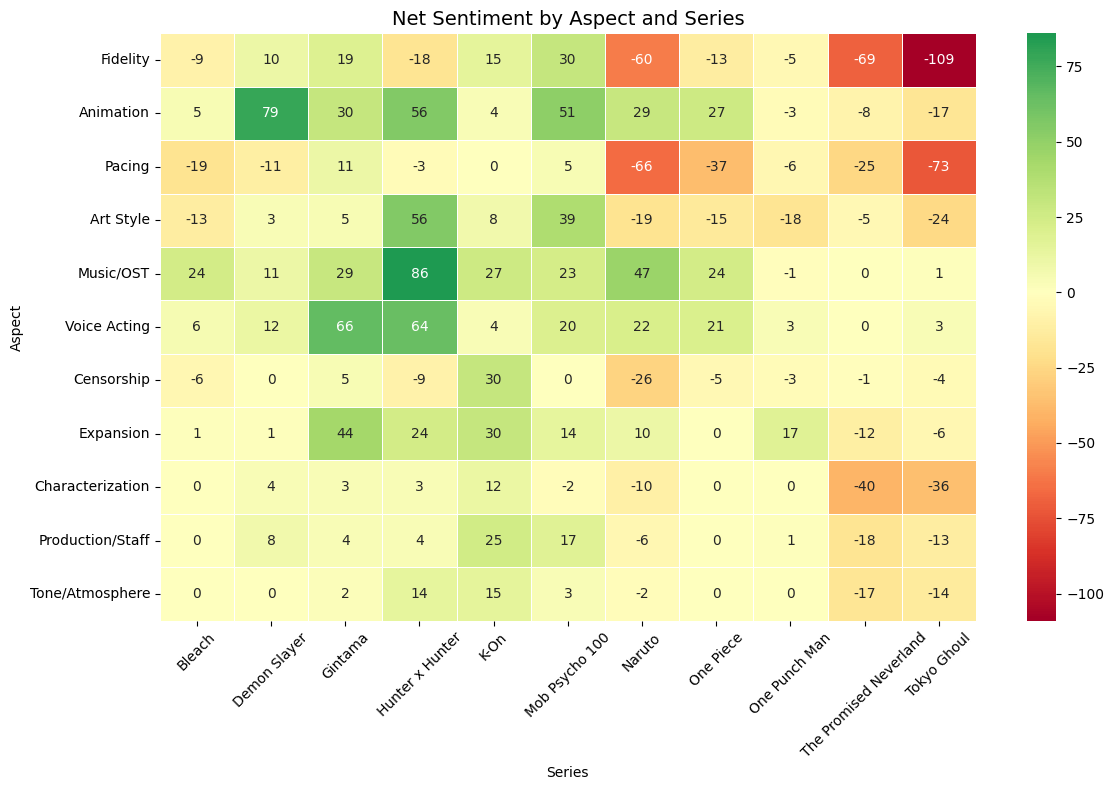

In [50]:
# Hitung net sentiment per aspect per series
aspect_sentiment = df_expanded.groupby(['Anime', 'aspect_clean', 'sentiment_clean']).size().unstack(fill_value=0)
aspect_sentiment['net'] = aspect_sentiment.get('positive', 0) - aspect_sentiment.get('negative', 0)
heatmap_data = aspect_sentiment['net'].unstack(level=0).fillna(0)

# Top 11 aspects (berdasarkan frekuensi kemunculan)
top_aspects = df_expanded['aspect_clean'].value_counts().head(11).index
heatmap_data = heatmap_data.loc[top_aspects]

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=0, fmt='.0f', linewidths=0.5)
plt.title('Net Sentiment by Aspect and Series', fontsize=14)
plt.xlabel('Series')
plt.ylabel('Aspect')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
print('Net Sentiment by Aspect and Series (Raw Counts):')
display(heatmap_data)

Net Sentiment by Aspect and Series (Raw Counts):


Anime,Bleach,Demon Slayer,Gintama,Hunter x Hunter,K-On,Mob Psycho 100,Naruto,One Piece,One Punch Man,The Promised Neverland,Tokyo Ghoul
aspect_clean,,,,,,,,,,,
Fidelity,-9.0,10.0,19.0,-18.0,15.0,30.0,-60.0,-13.0,-5.0,-69.0,-109.0
Animation,5.0,79.0,30.0,56.0,4.0,51.0,29.0,27.0,-3.0,-8.0,-17.0
Pacing,-19.0,-11.0,11.0,-3.0,0.0,5.0,-66.0,-37.0,-6.0,-25.0,-73.0
Art Style,-13.0,3.0,5.0,56.0,8.0,39.0,-19.0,-15.0,-18.0,-5.0,-24.0
Music/OST,24.0,11.0,29.0,86.0,27.0,23.0,47.0,24.0,-1.0,0.0,1.0
Voice Acting,6.0,12.0,66.0,64.0,4.0,20.0,22.0,21.0,3.0,0.0,3.0
Censorship,-6.0,0.0,5.0,-9.0,30.0,0.0,-26.0,-5.0,-3.0,-1.0,-4.0
Expansion,1.0,1.0,44.0,24.0,30.0,14.0,10.0,0.0,17.0,-12.0,-6.0
Characterization,0.0,4.0,3.0,3.0,12.0,-2.0,-10.0,0.0,0.0,-40.0,-36.0


**Findings:**

- 'Fidelity' shows the most polarized sentiment across series, ranging from strong positives in **Mob Psycho 100** (+30), **Gintama** (+19), and **K-On** (+15) to very strong negatives in **Tokyo Ghoul** (-109), **The Promised Neverland** (-69), and **Naruto** (-60). This indicates that adaptation faithfulness is highly dependent on how each series handles source material expectations.

- 'Animation' is one of the most consistently positive aspects overall, with strong performance in **Demon Slayer** (+79), **Hunter x Hunter** (+56), and **Mob Psycho 100** (+51). Only a few series show negative values such as **Tokyo Ghoul** (-17), **The Promised Neverland** (-8), and **One Punch Man** (-3), suggesting visual quality is a stable strength across adaptations.

- 'Music/OST' and 'Voice Acting' are the most stable positive aspects across the dataset. 'Music/OST' peaks in **Hunter x Hunter** (+86), **Naruto** (+47), and **Gintama** (+29), while 'Voice Acting' is consistently positive with strong values in **Gintama** (+66) and **Hunter x Hunter** (+64). This suggests audio-related elements are reliably well received across most series.

- 'Pacing', 'Characterization', and 'Tone/Atmosphere' form a mostly negative narrative-experience cluster. 'Pacing' is strongly negative overall, especially in **Naruto** (-66), **Tokyo Ghoul** (-73), and **One Piece** (-37). 'Characterization' is also weak in several series such as **The Promised Neverland** (-40) and **Tokyo Ghoul** (-36), while 'Tone/Atmosphere' shows smaller but consistent negatives in **The Promised Neverland** (-17) and **Tokyo Ghoul** (-14). This indicates structural and narrative execution issues are a recurring weakness in several adaptations.

- 'Art Style' shows mixed sentiment, with strong positives in **Hunter x Hunter** (+56) and **Mob Psycho 100** (+39), but notable negatives in **Tokyo Ghoul** (-24), **Naruto** (-19), and **One Punch Man** (-18), indicating that stylistic reception is highly series-dependent.

- 'Expansion' and 'Censorship' show moderate and variable sentiment. 'Expansion' is generally positive, led by **Gintama** (+44) and **K-On** (+30), while 'Censorship' is mixed with positives in **K-On** (+30) and **Gintama** (+5) but negatives in **Naruto** (-26) and **Tokyo Ghoul** (-4). These aspects are less dominant but still reflect meaningful differences in adaptation handling.

- 'Production/Staff' shows mild positive to neutral sentiment overall, with strongest values in **K-On** (+17) and **Hunter x Hunter** (+4), while negative values appear in **The Promised Neverland** (-18) and **Tokyo Ghoul** (-13), suggesting behind-the-scenes perception has limited but noticeable impact.


### **D. Positive & Negative Breakdown: Where Does Each Series Excel or Fail?**
The heatmap shows the net balance, but we also need the raw proportions. This stacked bar chart breaks down, for each series, how much each aspect contributes to its total positive sentiment. It helps us spot specific pain points and unique strengths.

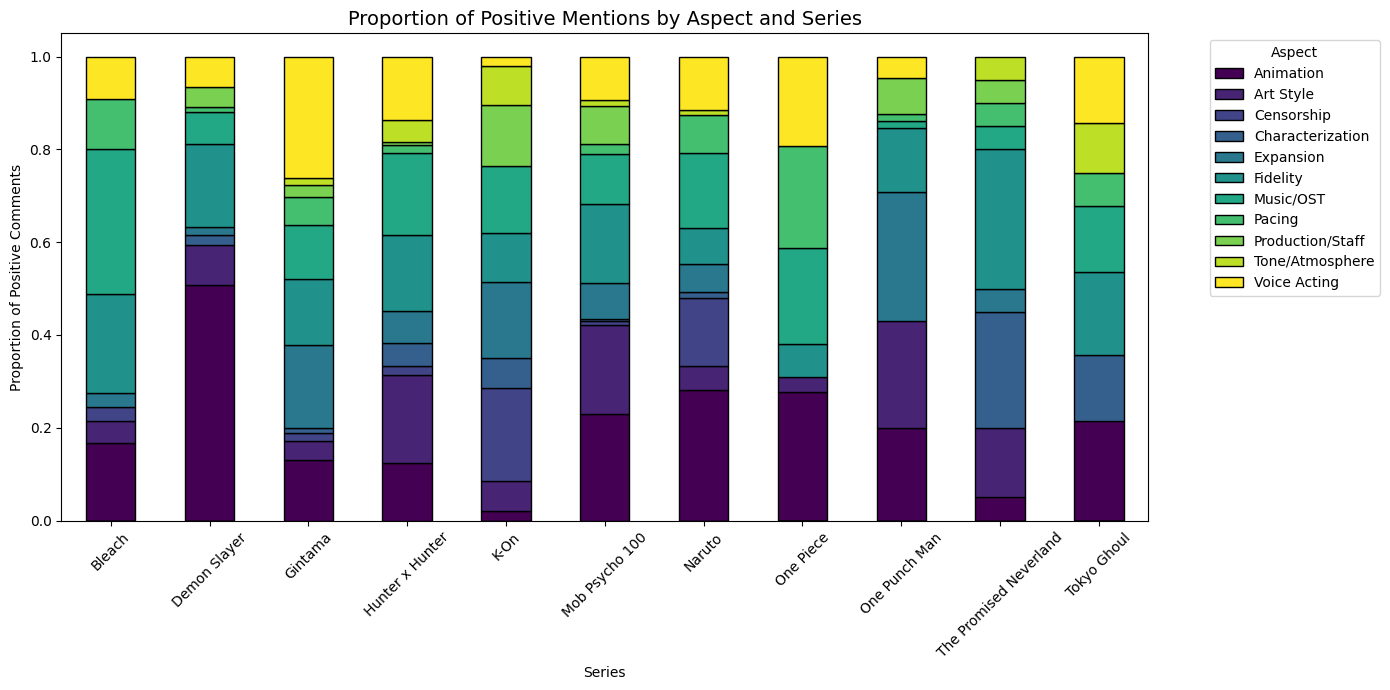

In [51]:
# For each series, count positive mentions per aspect
positive_only = df_expanded[df_expanded['sentiment_clean'] == 'positive']
aspect_series_pos = positive_only.groupby(['Anime', 'aspect_clean']).size().unstack(fill_value=0)

# Normalize to proportions (per series)
aspect_series_pos_norm = aspect_series_pos.div(aspect_series_pos.sum(axis=1), axis=0)

# Plot stacked bar
ax = aspect_series_pos_norm.plot(kind='bar', stacked=True, figsize=(14,7),
                                   colormap='viridis', edgecolor='black')
ax.set_title('Proportion of Positive Mentions by Aspect and Series', fontsize=14)
ax.set_xlabel('Series')
ax.set_ylabel('Proportion of Positive Comments')
ax.legend(title='Aspect', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [52]:
print("Positive Mentions by Aspect and Series:")
display(aspect_series_pos)

Positive Mentions by Aspect and Series:


aspect_clean,Animation,Art Style,Censorship,Characterization,Expansion,Fidelity,Music/OST,Pacing,Production/Staff,Tone/Atmosphere,Voice Acting
Anime,,,,,,,,,,,
Bleach,22,6,4,0,4,28,41,14,0,0,12
Demon Slayer,94,16,0,4,3,33,13,2,8,0,12
Gintama,36,11,5,3,49,39,32,17,7,4,72
Hunter x Hunter,65,99,10,26,36,85,93,8,4,25,71
K-On,4,13,40,13,33,21,29,0,26,17,4
Mob Psycho 100,51,43,2,1,17,38,24,5,18,3,21
Naruto,121,22,63,6,26,33,70,35,0,4,50
One Piece,52,6,0,0,0,13,39,41,0,0,36
One Punch Man,13,15,0,0,18,9,1,1,5,0,3


In [47]:
# Calculate total mentions per aspect
total_mentions_per_aspect = df_expanded.groupby('aspect_clean').size().rename('total_mentions')

# Calculate positive mentions per aspect
positive_mentions_per_aspect = df_expanded[df_expanded['sentiment_clean'] == 'positive']\
                                  .groupby('aspect_clean').size().rename('positive_mentions')

# Combine into a single DataFrame
aspect_positive_rates = pd.concat([total_mentions_per_aspect, positive_mentions_per_aspect], axis=1).fillna(0)

# Calculate positive rate
aspect_positive_rates['positive_rate'] = (aspect_positive_rates['positive_mentions'] / aspect_positive_rates['total_mentions']) * 100

# Sort by positive rate for clearer insights
aspect_positive_rates_sorted = aspect_positive_rates.sort_values(by='positive_rate', ascending=False)

print("Positive Rate per Aspect (Percentage of Positive Mentions out of Total Mentions):")
display(aspect_positive_rates_sorted)

Positive Rate per Aspect (Percentage of Positive Mentions out of Total Mentions):


,total_mentions,positive_mentions,positive_rate
aspect_clean,,,
Music/OST,423,347,82.033097
Voice Acting,349,285,81.661891
Expansion,252,187,74.206349
Animation,680,465,68.382353
Production/Staff,116,69,59.482759
Art Style,453,234,51.655629
Tone/Atmosphere,113,57,50.442478
Censorship,267,124,46.441948
Fidelity,833,310,37.214886


**Findings:**

- 'Music/OST' and 'Voice Acting' are the most positively received aspects in terms of positive rate. 'Music/OST' leads with a 82.0% positive rate, followed closely by 'Voice Acting' at 81.7%. This indicates that audio-related elements are the most consistently well-received aspects across anime adaptations, regardless of series differences.

- 'Expansion' (74.2%) and 'Animation' (68.4%) form the next tier of highly positive aspects. This suggests that both narrative expansion (e.g., additional content or adaptation depth) and visual execution are generally perceived positively, though slightly less consistently than audio elements.

- 'Production/Staff' (59.5%), 'Art Style' (51.7%), and 'Tone/Atmosphere' (50.4%) fall into a moderate sentiment range. These aspects are more context-dependent, showing balanced reception where positives and negatives are relatively evenly distributed.

- 'Censorship' (46.4%) and 'Fidelity' (37.2%) show weaker positive rates, indicating more divided audience reception. In particular, 'Fidelity' being below 40% suggests that adaptation faithfulness is often a point of criticism rather than consistent praise.

- 'Characterization' (32.3%) and 'Pacing' (26.5%) are the lowest-performing aspects in terms of positive rate. This indicates that narrative structure and character writing are the most frequently criticized areas across adaptations, making them the primary weakness in audience perception.

The results suggest a clear split between execution-based aspects (audio/visual) which are highly positively received, and narrative-based aspects (pacing, characterization, fidelity), which tend to receive more mixed or negative feedback.

### **E. Aspect Co-occurrence: Which Aspects Do Fans Discuss Together?**
Fans rarely talk about just one thing. By analyzing how often more than one aspects appear in the same comment, we see which concepts are mentally linked. This is important because it shows that criticism of one aspect often drags others along with it.

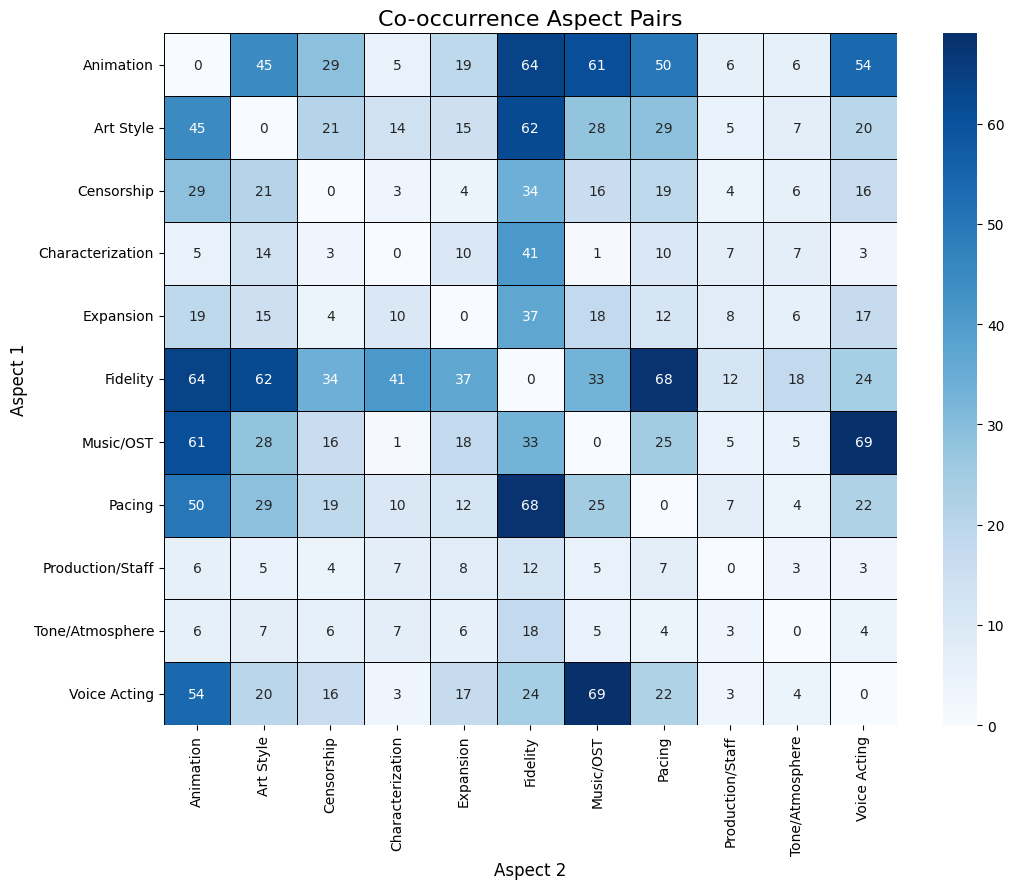

In [54]:
import itertools

# Get all unique aspects
all_unique_aspects = sorted(df_expanded['aspect_clean'].dropna().unique().tolist())

# Initialize a co-occurrence matrix
co_occurrence_matrix = pd.DataFrame(0, index=all_unique_aspects, columns=all_unique_aspects)

# Helper function to flatten potentially nested lists within an aspect list
def flatten_aspect_items(aspect_list_raw):
    processed_items = []
    for item in aspect_list_raw:
        if isinstance(item, list):
            # Flatten a nested list to its first element or an empty string
            processed_items.append(str(item[0]) if len(item) > 0 else '')
        else:
            # Assume it's already a string or can be converted to one
            processed_items.append(str(item))
    return processed_items

# Populate the co-occurrence matrix
for _, row in df.iterrows():
    # First, flatten any nested lists within row['aspect_list']
    processed_aspect_list = flatten_aspect_items(row['aspect_list'])
    # Then, get unique aspects and sort them
    aspects_in_comment = sorted(list(set(processed_aspect_list)))

    # Generate all unique pairs of aspects within the same comment
    if len(aspects_in_comment) >= 2:
        for pair in itertools.combinations(aspects_in_comment, 2):
            aspect1, aspect2 = pair
            co_occurrence_matrix.loc[aspect1, aspect2] += 1
            co_occurrence_matrix.loc[aspect2, aspect1] += 1 # Ensure symmetry

# Visualize the co-occurrence matrix with a heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(co_occurrence_matrix,
            annot=True, # Show the co-occurrence counts on the heatmap
            cmap='Blues', # Color map
            fmt='d', # Format annotations as integers
            linewidths=0.5, # Add lines between cells
            linecolor='black')
plt.title('Co-occurrence Aspect Pairs', fontsize=16)
plt.xlabel('Aspect 2', fontsize=12)
plt.ylabel('Aspect 1', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
print('Co-occurrence Aspect Pairs (Raw Counts):')
display(co_occurrence_matrix)

Co-occurrence Aspect Pairs (Raw Counts):


,Animation,Art Style,Censorship,Characterization,Expansion,Fidelity,Music/OST,Pacing,Production/Staff,Tone/Atmosphere,Voice Acting
Animation,0,45,29,5,19,64,61,50,6,6,54
Art Style,45,0,21,14,15,62,28,29,5,7,20
Censorship,29,21,0,3,4,34,16,19,4,6,16
Characterization,5,14,3,0,10,41,1,10,7,7,3
Expansion,19,15,4,10,0,37,18,12,8,6,17
Fidelity,64,62,34,41,37,0,33,68,12,18,24
Music/OST,61,28,16,1,18,33,0,25,5,5,69
Pacing,50,29,19,10,12,68,25,0,7,4,22
Production/Staff,6,5,4,7,8,12,5,7,0,3,3
Tone/Atmosphere,6,7,6,7,6,18,5,4,3,0,4


**Findings:**

Analysis of the aspect co-occurrence matrix reveals how different evaluation dimensions are commonly discussed together in anime adaptation discourse:

- **Fidelity acts as the strongest central connector across multiple aspects.** It co-occurs most frequently with 'Pacing' (68), 'Art Style' (62), 'Animation' (64), and 'Music/OST' (33). This suggests that discussions about source material faithfulness are rarely isolated and tend to appear alongside both narrative structure and production quality aspects.

- **Visual and audio elements form a tightly connected cluster.** High co-occurrence is observed between 'Animation' & 'Music/OST' (61), 'Music/OST' & 'Voice Acting' (69), and 'Animation' & 'Voice Acting' (54). This indicates that users often evaluate the audiovisual experience as a combined dimension rather than separate components.

- **'Art Style' and 'Animation' are strongly interlinked with both fidelity and audio aspects.** Notable co-occurrences include 'Animation' & 'Art Style' (45), 'Art Style' & 'Fidelity' (62), and 'Art Style' & 'Music/OST' (28), suggesting that visual design discussions frequently overlap with both adaptation faithfulness and production soundscape.

- **'Pacing' is strongly connected to both structural and core adaptation aspects.** It co-occurs frequently with 'Fidelity' (68), 'Animation' (50), and 'Art Style' (29), indicating that pacing issues are often discussed in relation to both narrative adaptation quality and visual execution.

- **Narrative-related aspects form a secondary interaction cluster.** 'Characterization', 'Expansion', and 'Censorship' show moderate co-occurrence with 'Fidelity' (41, 37, 34 respectively), suggesting that story depth, added content, and content alteration are commonly evaluated through the lens of adaptation faithfulness.

- **Production/Staff and Tone/Atmosphere remain weakly connected across most aspects.** Their co-occurrence values are generally low (mostly single digits to low teens), indicating that these aspects are discussed more independently rather than as part of broader evaluation clusters.

### **F. Proving the Hypothesis: Does 'Fidelity' Really Drive Overall Satisfaction?**
From the previous sections (B through E), 'Fidelity' stands out as the most discussed aspect, often negative, and highly connected to other aspects. Now, let's test quantitatively: does a comment's sentiment toward 'Fidelity' predict its overall sentiment toward the series? Using a scatterplot and Pearson correlation, we measure this relationship. If the correlation is positive and significant, it's strong evidence that staying faithful to the source material is the single most important factor for audience satisfaction.

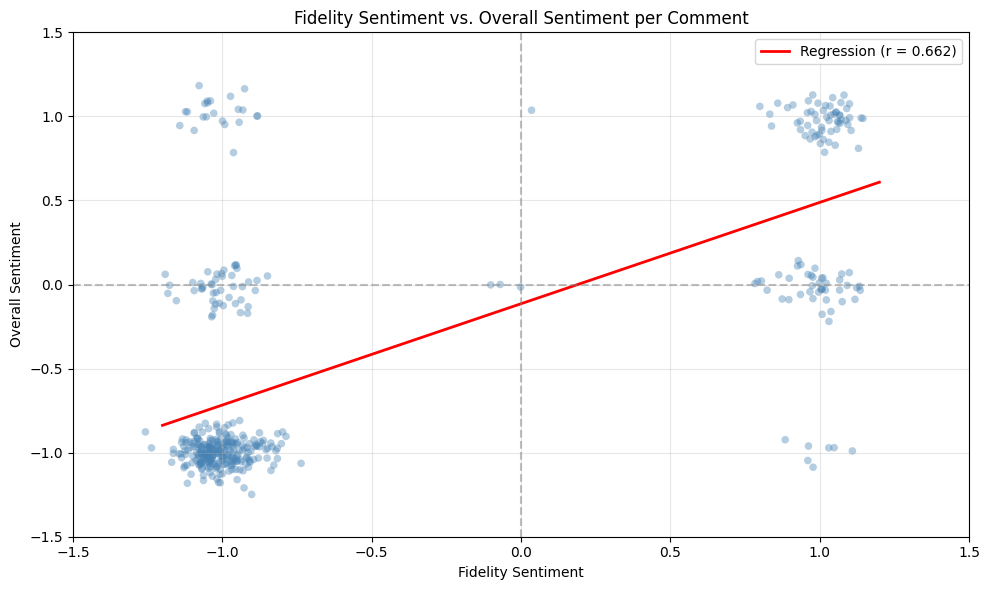

Pearson correlation coefficient (r): 0.6622
p-value: 1.7759e-55
Number of data mentioning the 'Fidelity' aspect: 429


In [56]:
# Fidelity sentiment vs Overall sentiment
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# --- Start of added code to define df_filtered and fidelity_sent ---
# For each comment, get fidelity sentiment (if mentioned)
def get_fidelity_sentiment(row):
    aspects = row['aspect_list']
    sentiments = row['sentiment_list']
    for a, s in zip(aspects, sentiments):
        if a == 'Fidelity':
            return sentiment_map.get(s, 0)
    return None

df['fidelity_sent'] = df.apply(get_fidelity_sentiment, axis=1)
df_filtered = df.dropna(subset=['fidelity_sent'])
# --- End of added code ---

plt.figure(figsize=(10, 6))

# Scatter plot with jitter
plt.scatter(df_filtered['fidelity_sent'] + np.random.normal(0, 0.08, size=len(df_filtered)),
            df_filtered['sentiment_num'] + np.random.normal(0, 0.08, size=len(df_filtered)),
            alpha=0.4, s=30, c='steelblue', edgecolors='none')

# Create a temporary DataFrame with the two columns and drop NaNs from both
temp_df = df_filtered[['fidelity_sent', 'sentiment_num']].dropna()

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(temp_df['fidelity_sent'],
                                                                temp_df['sentiment_num'])
x_line = np.array([-1.2, 1.2])
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Regression (r = {r_value:.3f})')

# Reference line
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Label and boundary
plt.title('Fidelity Sentiment vs. Overall Sentiment per Comment')
plt.xlabel('Fidelity Sentiment')
plt.ylabel('Overall Sentiment')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Output statistik
print(f"Pearson correlation coefficient (r): {r_value:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"Number of data mentioning the 'Fidelity' aspect: {len(df_filtered)}")

**Findings:**

- **Strong positive correlation:** r = 0.6622 indicates a moderately strong positive relationship between sentiment toward 'Fidelity' and overall sentiment toward the series. This suggests that when users evaluate fidelity positively, they are also more likely to evaluate the series positively overall.

- **Statistical significance:** The p-value = 1.7759e-55 (< 0.05) indicates that this relationship is extremely statistically significant and highly unlikely to occur by random chance.

- **Consistent alignment pattern:** The distribution of points shows a strong concentration in the bottom-left and top-right quadrants, indicating that sentiment toward 'Fidelity' and overall sentiment tend to move in the same direction for most observations.

- **Limited but present deviations:** A small number of mismatched cases exist (e.g., positive fidelity but negative overall sentiment, or vice versa), suggesting that while fidelity is influential, it is not the sole determinant of overall reception.

'Fidelity' demonstrates a meaningful predictive relationship with overall sentiment, reinforcing its role as an important factor in audience evaluation of anime adaptations.

g. Word Clouds per Series

Generating word clouds for 11 series: ['Naruto' 'Demon Slayer' 'Bleach' 'One Piece' 'Tokyo Ghoul' 'Gintama'
 'The Promised Neverland' 'K-On' 'One Punch Man' 'Mob Psycho 100'
 'Hunter x Hunter']


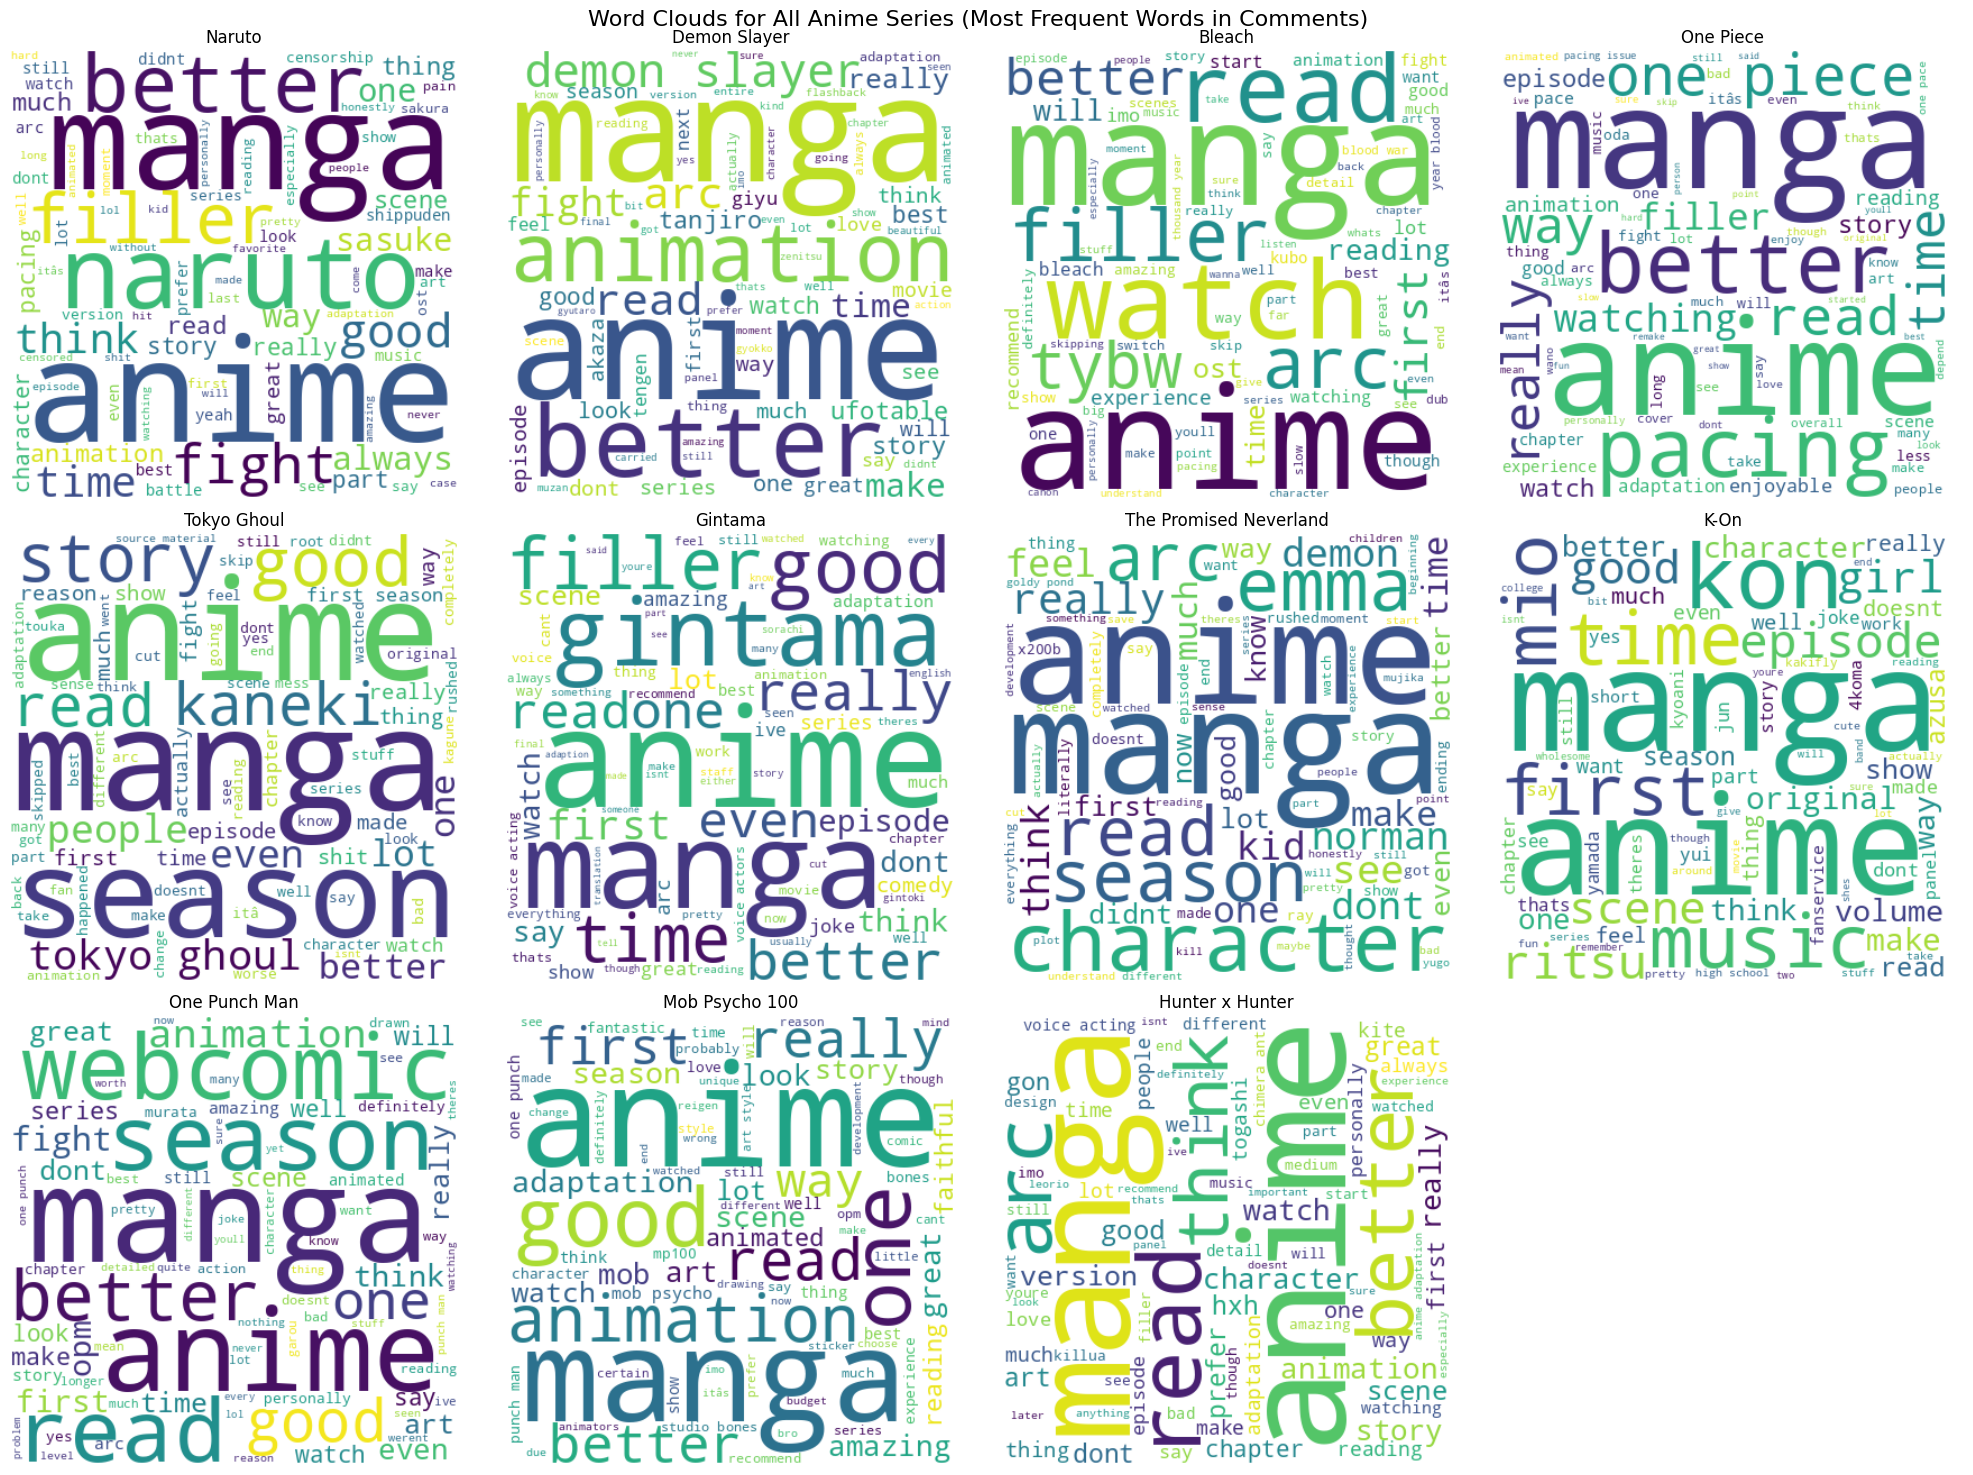

In [ ]:
import math

# Get all unique series (sorted alphabetically or by count)
all_series = df['Anime'].unique()
n_series = len(all_series)
print(f"Generating word clouds for {n_series} series: {all_series}")

# Calculate grid dimensions (rows x columns)
cols = min(4, n_series)  # at most 4 columns
rows = math.ceil(n_series / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
# Flatten axes for easy indexing (if only 1 row, axes may not be 2D)
if rows == 1 and cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Preprocess text function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    words = [w for w in text.split() if len(w) > 2]  # keep words >2 chars
    return ' '.join(words)

# Generate word cloud for each series
for idx, series in enumerate(all_series):
    # Combine all text comments for this series
    series_text = ' '.join(df[df['Anime'] == series]['Text'].dropna().apply(clean_text))

    if series_text.strip():
        wordcloud = WordCloud(width=400, height=400, background_color='white',
                              colormap='viridis', max_words=80).generate(series_text)
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'{series}', fontsize=12)
    else:
        axes[idx].text(0.5, 0.5, f'No text data\nfor {series}', ha='center', va='center', fontsize=10)
    axes[idx].axis('off')

# Hide any unused subplots
for idx in range(n_series, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Word Clouds for All Anime Series (Most Frequent Words in Comments)', fontsize=16)
plt.tight_layout()
plt.show()

h. Comparative Radar Chart (Naruto as example) Compare Anime strengths vs Manga strengths

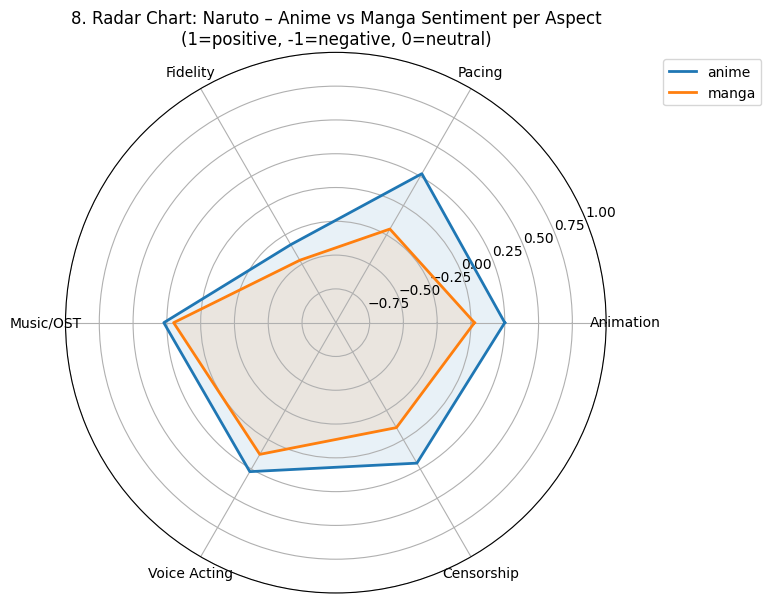

In [ ]:
# For a single series (Naruto), classify comments as anime-praising or manga-praising
naruto_df = df[df['Anime'] == 'Naruto'].copy()

# Keywords for anime vs manga preference
def classify_preference(text):
    text_lower = str(text).lower()
    if any(word in text_lower for word in ['anime is better', 'watch the anime', 'anime wins', 'anime >']):
        return 'anime_favor'
    elif any(word in text_lower for word in ['manga is better', 'read the manga', 'manga wins', 'manga >']):
        return 'manga_favor'
    else:
        return 'neutral'

naruto_df['pref'] = naruto_df['Text'].apply(classify_preference)

# Average sentiment per aspect for each preference group
naruto_expanded = naruto_df.explode('aspect_list').explode('sentiment_list')
naruto_expanded = naruto_expanded[naruto_expanded['aspect_list'] != '']
naruto_expanded['sent_num'] = naruto_expanded['sentiment_list'].map(sentiment_map)

# Pivot: average sentiment by aspect and preference
pivot_radar = naruto_expanded.groupby(['pref', 'aspect_list'])['sent_num'].mean().unstack().fillna(0)

# Select common aspects
common_aspects = ['Animation', 'Pacing', 'Fidelity', 'Music/OST', 'Voice Acting', 'Censorship']
pivot_radar = pivot_radar[common_aspects]

# Radar chart
angles = np.linspace(0, 2*np.pi, len(common_aspects), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for label in pivot_radar.index:
    if label in ['anime_favor', 'manga_favor']:
        values = pivot_radar.loc[label].values.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=label.replace('_favor', ''))
        ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(common_aspects, fontsize=10)
ax.set_ylim(-1, 1)
ax.set_title('8. Radar Chart: Naruto – Anime vs Manga Sentiment per Aspect\n(1=positive, -1=negative, 0=neutral)', fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)
plt.tight_layout()
plt.show()

i. Series Ranking by "Most Divisive" (Standard deviation of overall sentiment per series)

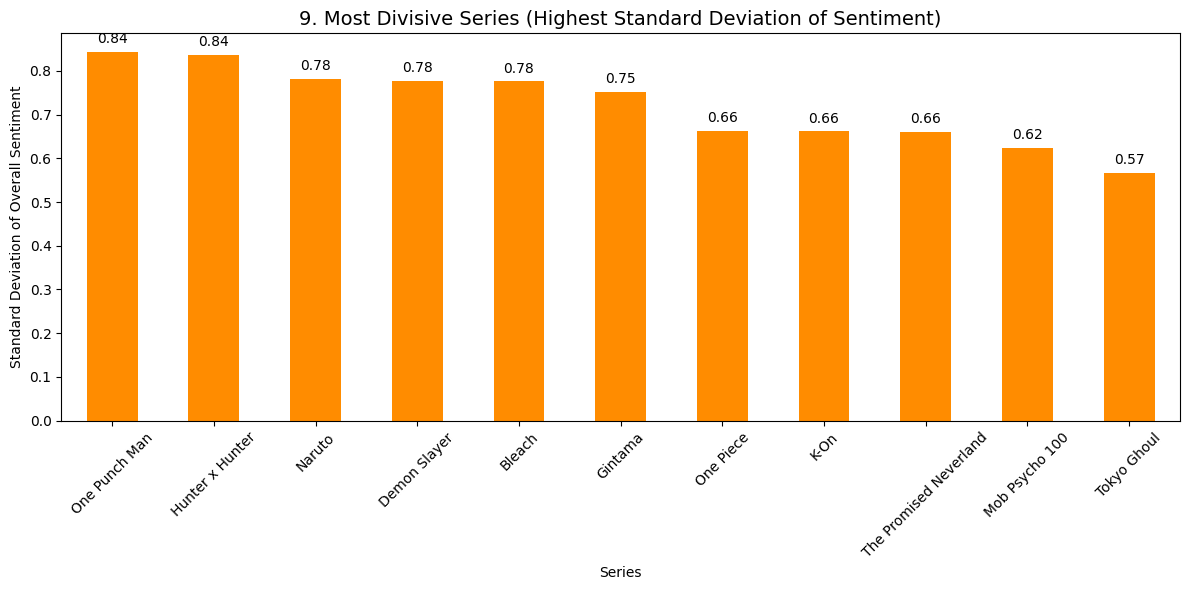


Series ranked by divisiveness (most controversial first):
Anime
One Punch Man             0.843859
Hunter x Hunter           0.836573
Naruto                    0.781075
Demon Slayer              0.777313
Bleach                    0.776065
Gintama                   0.751361
One Piece                 0.663387
K-On                      0.661888
The Promised Neverland    0.660131
Mob Psycho 100            0.624609
Tokyo Ghoul               0.567534
Name: sentiment_num, dtype: float64


In [ ]:
# Calculate standard deviation of numeric sentiment per series
divisiveness = df.groupby('Anime')['sentiment_num'].std().sort_values(ascending=False)

plt.figure(figsize=(12,6))
divisiveness.plot(kind='bar', color='darkorange')
plt.title('9. Most Divisive Series (Highest Standard Deviation of Sentiment)', fontsize=14)
plt.xlabel('Series')
plt.ylabel('Standard Deviation of Overall Sentiment')
plt.xticks(rotation=45)
for i, v in enumerate(divisiveness):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

print("\nSeries ranked by divisiveness (most controversial first):")
print(divisiveness)